# Animal Crossing Overview
## By: Matthew Gonzales

In [362]:
# Importing the important stuff
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import requests as re
import seaborn as sns
import statistics

In [183]:
# Reading in the datasets
acc = pd.read_csv("accessories.csv")
bags = pd.read_csv("bags.csv")
bottoms = pd.read_csv("bottoms.csv")
dress_up = pd.read_csv("dress-up.csv")
headwear = pd.read_csv("headwear.csv")
shoes = pd.read_csv("shoes.csv")
socks = pd.read_csv("socks.csv")
tops = pd.read_csv("tops.csv")
villagers = pd.read_csv("villagers.csv")

In [184]:
villagers.head()

,Name,Species,Gender,Personality,Hobby,Birthday,Catchphrase,Favorite Song,Style 1,Style 2,Color 1,Color 2,Wallpaper,Flooring,Furniture List,Filename,Unique Entry ID
0,Admiral,Bird,Male,Cranky,Nature,27-Jan,aye aye,Steep Hill,Cool,Cool,Black,Blue,dirt-clod wall,tatami,717;1849;7047;2736;787;5970;3449;3622;3802;410...,brd06,B3RyfNEqwGmcccRC3
1,Agent S,Squirrel,Female,Peppy,Fitness,2-Jul,sidekick,Go K.K. Rider,Active,Simple,Blue,Black,concrete wall,colorful tile flooring,7845;7150;3468;4080;290;3971;3449;1708;4756;25...,squ05,SGMdki6dzpDZyXAw5
2,Agnes,Pig,Female,Big Sister,Play,21-Apr,snuffle,K.K. House,Simple,Elegant,Pink,White,gray molded-panel wall,arabesque flooring,4129;7236;7235;7802;896;3428;4027;7325;3958;71...,pig17,jzWCiDPm9MqtCfecP
3,Al,Gorilla,Male,Lazy,Fitness,18-Oct,ayyyeee,Go K.K. Rider,Active,Active,Red,White,concrete wall,green rubber flooring,1452;4078;4013;833;4116;3697;7845;3307;3946;39...,gor08,LBifxETQJGEaLhBjC
4,Alfonso,Alligator,Male,Lazy,Play,9-Jun,it'sa me,Forest Life,Simple,Simple,Red,Blue,yellow playroom wall,green honeycomb tile,4763;3205;3701;1557;3623;85;3208;3584;4761;121...,crd00,REpd8KxB8p9aGBRSE


In [14]:
acc.head(5)

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,...,Mannequin Piece,Version,Style,Label Themes,Type,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,3D glasses,White,No,490,122,White,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed0,4463,FNxEraBTeWRiCvtFu
1,3D glasses,Black,No,490,122,Black,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed1,11020,mM9SXPCcGPfPJAmtm
2,bandage,Beige,No,140,35,Beige,White,1x1,NaN,Able Sisters,...,Yes,1.0.0,Active,outdoorsy; comfy; sporty,AccessoryMouth,No,For sale,AccessoryMouthBandageSkin,4677,2qFT5iPkk8bREvpkj
3,beak,Yellow,No,490,122,Yellow,Yellow,1x1,NaN,Able Sisters,...,Yes,1.0.0,Cute,fairy tale; party; theatrical,AccessoryMouthInvisibleNose,No,For sale,AccessoryMouthBeakYellow,3549,T5CpsJi4xBSachNL5
4,birthday shades,Yellow,No,NFS,620,Yellow,Red,1x1,NaN,Birthday,...,No,1.0.0,Gorgeous,party,AccessoryEye,Yes,Not for sale,AccessoryGlassBirthday0,4510,S6CiB9ZvzBTMhEnDz


In [13]:
bags.head(5)

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,Source Notes,Seasonal Availability,Version,Style,Label Themes,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,acorn pochette,Brown,Yes,NFS,2400,Brown,Green,1x1,NaN,Crafting,NaN,All Year,1.0.0,Cute,fairy tale,No,Not for sale,BagShoulderAcorn0,7492,XiC7bNzTBAdb8zWwr
1,basket pack,Green,Yes,NFS,2400,Green,Green,1x1,NaN,Crafting,NaN,All Year,1.0.0,Simple,outdoorsy; work,No,Not for sale,BagBackpackBasket0,7506,BW764rj9aH3QL6GRH
2,bug cage,Green,No,NFS,122,Green,White,1x1,NaN,Bug-Off,NaN,All Year,1.0.0,Active,outdoorsy; vacation,No,Not for sale,BagShoulderCage0,7479,nrkEKkL46YsQYcYjp
3,Bunny Day bag,NaN,Yes,NFS,2400,Colorful,Colorful,1x1,NaN,Crafting,NaN,All Year,1.1.0a,Active,fairy tale; party; theatrical,No,Not for sale,BagBackpackEgg0,12447,YGofzAZknSTYWmfWM
4,butterfly backpack,Pink,No,NFS,210,Pink,Yellow,1x1,NaN,Bug-Off,NaN,All Year,1.0.0,Cute,everyday; formal; party,No,Not for sale,BagBackpackButterfly0,7502,unsmeHZemRaTnq62z


In [71]:
#Cleaning and combining the Datasets
files = [
    "accessories.csv",
    "bags.csv",
    "bottoms.csv",
    "dress-up.csv",
    "headwear.csv",
    "shoes.csv",
    "socks.csv",
    "tops.csv"
]

wears = [pd.read_csv(f) for f in files]
wearables = (
    pd.concat(wears)
      .drop_duplicates(subset="Name", keep="first")
      .reset_index(drop=True)
)
wearables["Name"] = wearables["Name"].str.capitalize()
wearables = wearables.sort_values("Name").reset_index(drop=True)
# acc["Name"] = acc["Name"].str.capitalize()
# bags["Name"] = bags["Name"].str.capitalize()
# wearables = acc.set_index("Name").combine_first(bags.set_index("Name")).reset_index()

In [72]:
wearables.columns

Index(['Name', 'Variation', 'DIY', 'Buy', 'Sell', 'Color 1', 'Color 2', 'Size',
       'Miles Price', 'Source', 'Source Notes', 'Seasonal Availability',
       'Mannequin Piece', 'Version', 'Style', 'Label Themes', 'Type',
       'Villager Equippable', 'Catalog', 'Filename', 'Internal ID',
       'Unique Entry ID', 'Primary Shape', 'Secondary Shape'],
      dtype='object')

In [74]:
wearables = wearables.drop(["Primary Shape", "Miles Price", "Secondary Shape", "Source Notes", "Mannequin Piece", "Version", "Type" , "Filename", "Internal ID", "Unique Entry ID"] , axis=1)

In [75]:
wearables

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Source,Seasonal Availability,Style,Label Themes,Villager Equippable,Catalog
0,3d glasses,White,No,490,122,White,Colorful,1x1,Able Sisters,All Year,Active,party,Yes,For sale
1,A tee,NaN,No,560,140,Blue,White,1x1,Nook Shopping Catalog,All Year,Simple,everyday; comfy,Yes,For sale
2,Academy uniform,Navy blue,No,2080,520,Blue,White,1x1,Able Sisters,All Year,Elegant,formal; party,Yes,For sale
3,Acid-washed jacket,Blue,No,1680,420,Blue,Blue,1x1,Able Sisters,All Year,Simple,everyday; outdoorsy,Yes,For sale
4,Acid-washed jeans,Blue,No,1320,330,Blue,Blue,1x1,Able Sisters,All Year,Simple,everyday; outdoorsy,No,For sale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136,Zen hair clip,Red,No,4300,1075,Red,White,1x1,Able Sisters,All Year,Cute,formal; party,Yes,For sale
1137,Zigzag shirt,NaN,No,960,240,Green,Red,1x1,Nook Shopping Catalog,All Year,Active,everyday; comfy,Yes,For sale
1138,Zigzag-print dress,Purple,No,2000,500,Purple,Blue,1x1,Able Sisters,Summer,Elegant,vacation,Yes,For sale
1139,Zori,Black,No,4300,1075,Red,Black,1x1,Able Sisters,All Year,Elegant,everyday; formal; party,No,For sale


In [79]:
wearables.dtypes

Name                     object
Variation                object
DIY                      object
Buy                      object
Sell                      int64
Color 1                  object
Color 2                  object
Size                     object
Source                   object
Seasonal Availability    object
Style                    object
Label Themes             object
Villager Equippable      object
Catalog                  object
dtype: object

In [83]:
ColumnNamesList = wearables.columns.values
ColumnNamesList
wearables["Buy"]

array(['Name', 'Variation', 'DIY', 'Buy', 'Sell', 'Color 1', 'Color 2',
       'Size', 'Source', 'Seasonal Availability', 'Style', 'Label Themes',
       'Villager Equippable', 'Catalog'], dtype=object)

In [116]:
wearables.replace("NFS", 0, inplace=True)

In [118]:
wearables["Buy"]= wearables["Buy"].astype('int64')

In [128]:
wearables.dtypes

Name                     object
Variation                object
DIY                      object
Buy                       int64
Sell                      int64
Color 1                  object
Color 2                  object
Size                     object
Source                   object
Seasonal Availability    object
Style                    object
Label Themes             object
Villager Equippable      object
Catalog                  object
dtype: object

In [144]:
counts = wearables["Seasonal Availability"].value_counts()
counts
freqs = Counter[wearables['Seasonal Availability']]

Text(0.5, 1.0, 'Items Available by Season')

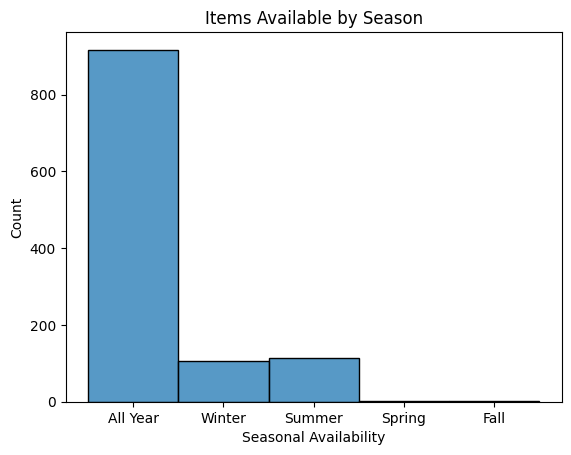

In [333]:
sns.histplot(wearables["Seasonal Availability"])
plt.title("Items Available by Season")

<Axes: xlabel='Count', ylabel='Source'>

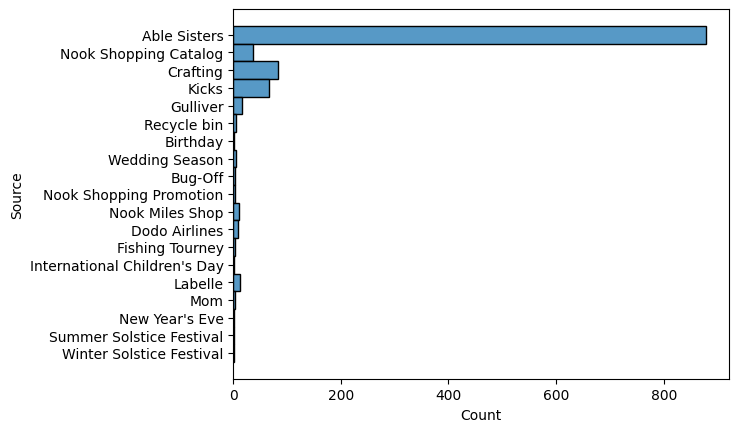

In [344]:
sns.histplot(y=wearables["Source"])
#plt.xticks(rotation=90);

Text(0.5, 1.0, 'Distribution of DIY vs. Non-DIY Items')

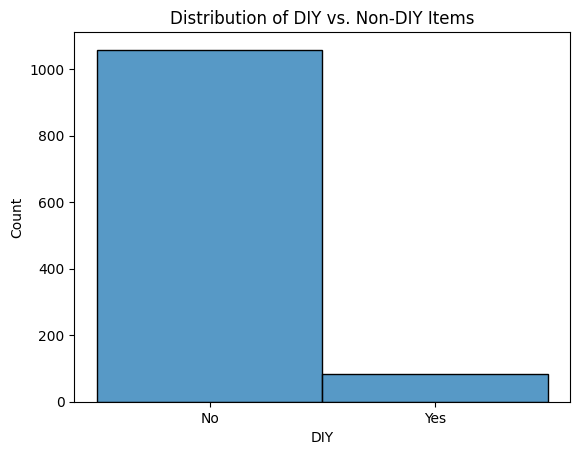

In [384]:
sns.histplot(wearables["DIY"])
plt.title("Distribution of DIY vs. Non-DIY Items")         

Text(0, 0.5, 'Bells')

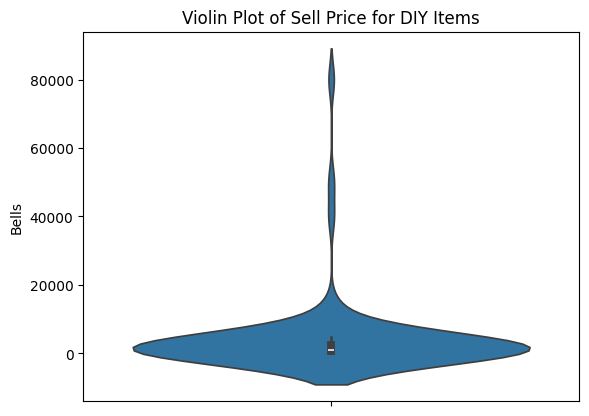

In [375]:
diy_yes = wearables[wearables["DIY"]=="Yes"]
price = diy_yes["Sell"]
sns.violinplot(y=price)
plt.title("Violin Plot of Sell Price for DIY Items")
plt.ylabel("Bells")

Text(0, 0.5, 'Bells')

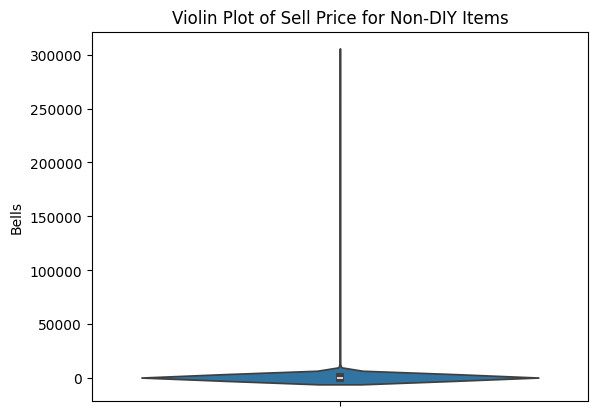

In [377]:
diy_no = wearables[wearables["DIY"]=="No"]
price = diy_no["Sell"]
sns.violinplot(y=price)
plt.title("Violin Plot of Sell Price for Non-DIY Items")
plt.ylabel("Bells")

(array([723.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 418.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

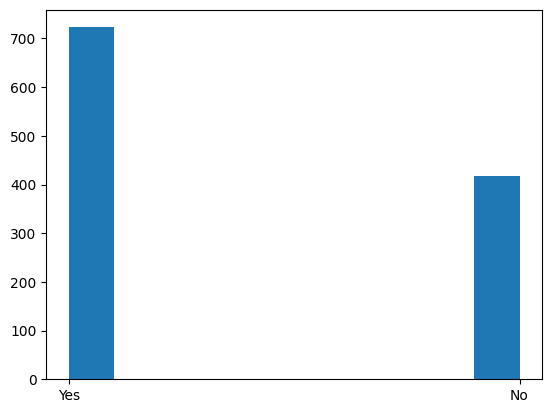

In [150]:
plt.hist(wearables["Villager Equippable"])

{'whiskers': [<matplotlib.lines.Line2D at 0x127131db0>,
 'caps': [<matplotlib.lines.Line2D at 0x1271322f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x127131b10>],
 'medians': [<matplotlib.lines.Line2D at 0x127132830>],
 'fliers': [<matplotlib.lines.Line2D at 0x127132ad0>],
 'means': []}

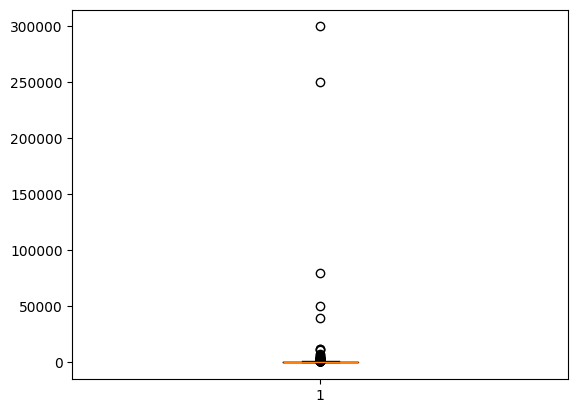

In [176]:
plt.boxplot(wearables["Sell"])

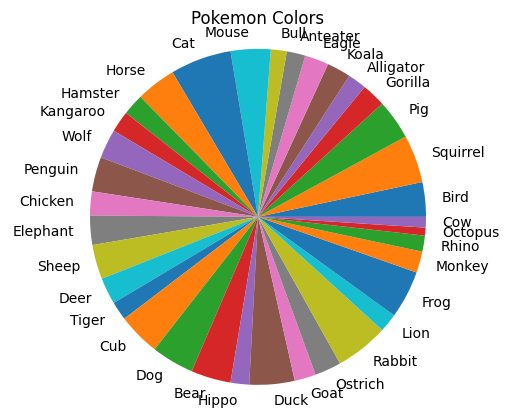

In [178]:
plt.figure()
animals = dict()
for a in villagers["Species"]:
  if a not in animals:
      animals[a] = 1
  else:
      animals[a] += 1
animalslabels = animals.keys()
animals_vals = [animals[a] for a in animalslabels]
plt.pie(animals_vals, labels=animalslabels)
plt.axis("equal")
plt.title("Pokemon Colors")
plt.show()

In [181]:
animals_vals

[13,
 18,
 15,
 9,
 7,
 9,
 9,
 7,
 6,
 15,
 23,
 15,
 8,
 8,
 11,
 13,
 9,
 11,
 13,
 10,
 7,
 16,
 16,
 15,
 7,
 17,
 8,
 10,
 20,
 7,
 18,
 8,
 6,
 3,
 4]

In [213]:
freq_of_vill = pd.DataFrame(list(zip(animalslabels, animals_vals)), columns=['Species', 'Number'])
freq_of_vill["perc"]=freq_of_vill["Number"]/sum(freq_of_vill["Number"])*100
top_n = freq_of_vill.nlargest(8, "Number")  # Returns all columns for the top 5
print(top_n)

     Species  Number      perc
10       Cat      23  5.882353
28    Rabbit      20  5.115090
1   Squirrel      18  4.603581
30      Frog      18  4.603581
25      Duck      17  4.347826
21       Cub      16  4.092072
22       Dog      16  4.092072
2        Pig      15  3.836317


In [214]:
bottom_n = freq_of_vill.nsmallest(8, "Number")  # Returns all columns for the top 5
print(bottom_n)

      Species  Number      perc
33    Octopus       3  0.767263
34        Cow       4  1.023018
8        Bull       6  1.534527
32      Rhino       6  1.534527
4   Alligator       7  1.790281
7    Anteater       7  1.790281
20      Tiger       7  1.790281
24      Hippo       7  1.790281


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Octopus'),
  Text(1, 0, 'Cow'),
  Text(2, 0, 'Bull'),
  Text(3, 0, 'Rhino'),
  Text(4, 0, 'Alligator'),
  Text(5, 0, 'Anteater'),
  Text(6, 0, 'Tiger'),
  Text(7, 0, 'Hippo')])

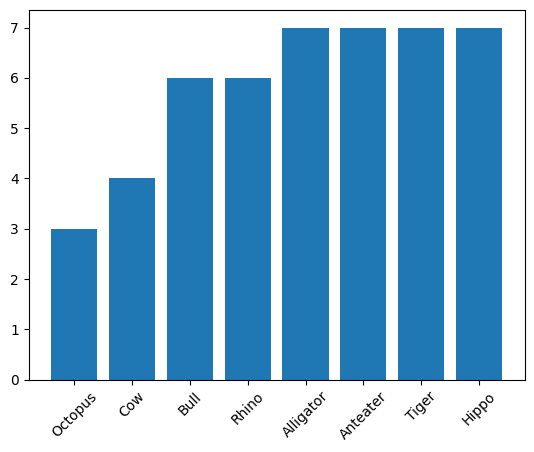

In [215]:
plt.bar(x=bottom_n["Species"], height=bottom_n["Number"])
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Cat'),
  Text(1, 0, 'Rabbit'),
  Text(2, 0, 'Squirrel'),
  Text(3, 0, 'Frog'),
  Text(4, 0, 'Duck'),
  Text(5, 0, 'Cub'),
  Text(6, 0, 'Dog'),
  Text(7, 0, 'Pig')])

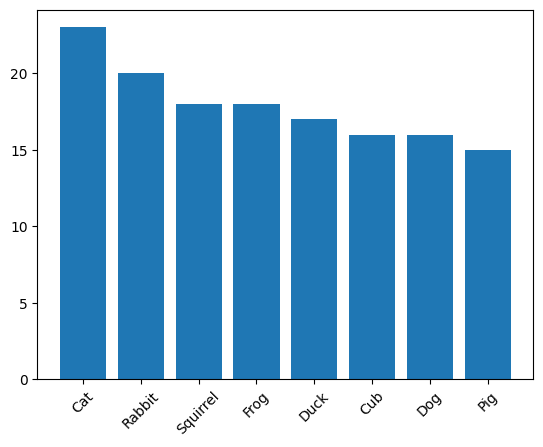

In [211]:
plt.bar(x=top_n["Species"], height=top_n["Number"])
plt.xticks(rotation=45)

In [307]:
api_endpoint = "https://api.nookipedia.com/nh/fish"
api_endpoint_2 = "https://api.nookipedia.com/nh/bugs"
api_key = "a34fd9c2-fcf1-4a95-ba6b-9d80aeb3989e"

In [ ]:
query = "%s?api_key=%s" % (api_endpoint, api_key)
response = re.get(query).json()
response

In [309]:
query = "%s?api_key=%s" % (api_endpoint_2, api_key)
response_2 = re.get(query).json()
response_2

[{'name': 'agrias butterfly',
  'url': 'https://nookipedia.com/wiki/Agrias%20butterfly',
  'number': 10,
  'image_url': 'https://dodo.ac/np/images/6/60/Agrias_Butterfly_NH_Icon.png',
  'render_url': 'https://dodo.ac/np/images/d/db/Agrias_Butterfly_NH.png',
  'location': 'Flying near flowers',
  'weather': 'Any except rain',
  'rarity': '',
  'total_catch': 20,
  'sell_nook': 3000,
  'sell_flick': 4500,
  'tank_width': 1.0,
  'tank_length': 1.0,
  'catchphrases': ['I caught an agrias butterfly! I wonder if it finds me disagrias-able?'],
  'north': {'availability_array': [{'months': 'Apr – Sep',
     'time': '8 AM – 5 PM'}],
   'times_by_month': {'1': 'NA',
    '2': 'NA',
    '3': 'NA',
    '4': '8 AM – 5 PM',
    '5': '8 AM – 5 PM',
    '6': '8 AM – 5 PM',
    '7': '8 AM – 5 PM',
    '8': '8 AM – 5 PM',
    '9': '8 AM – 5 PM',
    '10': 'NA',
    '11': 'NA',
    '12': 'NA'},
   'months': 'Apr – Sep',
   'months_array': [4, 5, 6, 7, 8, 9]},
  'south': {'availability_array': [{'months': '

In [380]:
bug_data = []

for bug in response_2:
    base = {
        "name": bug["name"],
        "location": bug["location"],
        "weather": bug["weather"],
        "nook_price": bug["sell_nook"],
        "flick_price": bug["sell_flick"]
    }

    # North hemisphere
    for month, time in fish["north"]["times_by_month"].items():
        bug_data.append({
            **base,
            "hemisphere": "north",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

    # South hemisphere
    for month, time in bug["south"]["times_by_month"].items():
        bug_data.append({
            **base,
            "hemisphere": "south",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

bug_data = pd.DataFrame(bug_data)
bug_data

,name,location,weather,nook_price,flick_price,hemisphere,month,time,available
0,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,1,NA,False
1,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,2,NA,False
2,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,3,NA,False
3,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,4,All day,True
4,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,5,All day,True
...,...,...,...,...,...,...,...,...,...
1915,Yellow butterfly,Flying,Any except rain,160,240,south,8,NA,False
1916,Yellow butterfly,Flying,Any except rain,160,240,south,9,4 AM – 7 PM,True
1917,Yellow butterfly,Flying,Any except rain,160,240,south,10,4 AM – 7 PM,True
1918,Yellow butterfly,Flying,Any except rain,160,240,south,11,4 AM – 7 PM,True


<Axes: xlabel='Gender', ylabel='Count'>

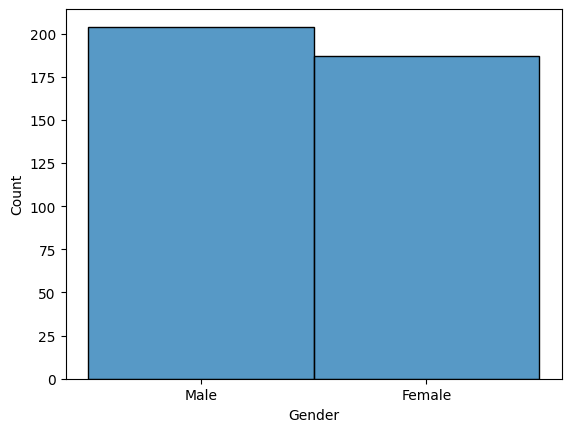

In [345]:
sns.histplot(villagers["Gender"])

In [331]:
unique_bug = bug_data.drop_duplicates(subset=["name"]).copy()
unique_bug

,name,location,weather,nook_price,flick_price,hemisphere,month,time,available
0,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,1,NA,False
24,ant,On/near spoiled turnips/candy/lollipops,Any weather,80,120,north,1,NA,False
48,Atlas moth,On trees (any kind),Any weather,3000,4500,north,1,NA,False
72,bagworm,Shaking trees (hardwood and cedar),Any weather,600,900,north,1,NA,False
96,banded dragonfly,Flying near water,Any except rain,4500,6750,north,1,NA,False
...,...,...,...,...,...,...,...,...,...
1800,walking leaf,Disguised under trees,Any weather,600,900,north,1,NA,False
1824,walking stick,On trees (any kind),Any weather,600,900,north,1,NA,False
1848,wasp,Shaking non-fruit hardwood trees or cedar trees,Any weather,2500,3750,north,1,NA,False
1872,wharf roach,On beach rocks,Any weather,200,300,north,1,NA,False


In [314]:
fish_data = []

for fish in response:
    base = {
        "name": fish["name"],
        "location": fish["location"],
        "shadow_size": fish["shadow_size"],
        "rarity": fish["rarity"],
        "nook_price": fish["sell_nook"],
        "cj_price": fish["sell_cj"]
    }

    # North hemisphere
    for month, time in fish["north"]["times_by_month"].items():
        fish_data.append({
            **base,
            "hemisphere": "north",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

    # South hemisphere
    for month, time in fish["south"]["times_by_month"].items():
        fish_data.append({
            **base,
            "hemisphere": "south",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

fish_data = pd.DataFrame(fish_data)
fish_data

,name,location,shadow_size,rarity,nook_price,cj_price,hemisphere,month,time,available
0,Anchovy,Sea,Small,Uncommon,200,300,north,1,4 AM – 9 PM,True
1,Anchovy,Sea,Small,Uncommon,200,300,north,2,4 AM – 9 PM,True
2,Anchovy,Sea,Small,Uncommon,200,300,north,3,4 AM – 9 PM,True
3,Anchovy,Sea,Small,Uncommon,200,300,north,4,4 AM – 9 PM,True
4,Anchovy,Sea,Small,Uncommon,200,300,north,5,4 AM – 9 PM,True
...,...,...,...,...,...,...,...,...,...,...
1915,Zebra turkeyfish,Sea,Medium,Common,500,750,south,8,NA,False
1916,Zebra turkeyfish,Sea,Medium,Common,500,750,south,9,NA,False
1917,Zebra turkeyfish,Sea,Medium,Common,500,750,south,10,All day,True
1918,Zebra turkeyfish,Sea,Medium,Common,500,750,south,11,All day,True


In [284]:
unique_fish = fish_data.drop_duplicates(subset=["name"]).copy()
unique_fish['shadow_size'] = pd.Categorical(unique_fish['shadow_size'], categories=['Tiny', 'Small', 'Medium', 'Large',
                                                                                    'Very large', "Huge", 'Very large (finned)', 'Long'], ordered=True)

Text(0.5, 0, 'Shadow Size')

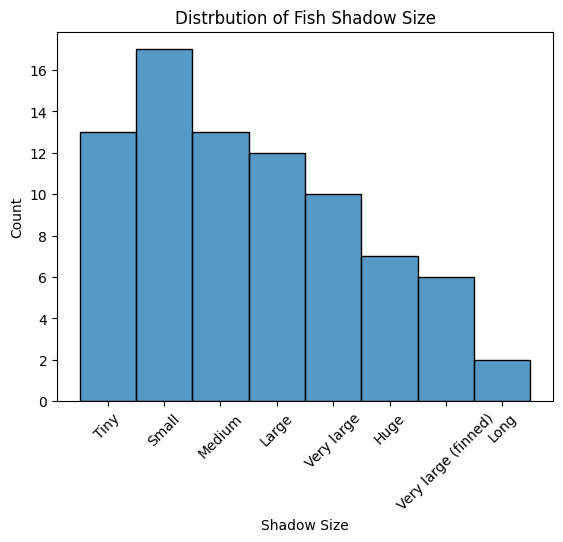

In [291]:
sns.histplot(unique_fish["shadow_size"])
plt.xticks(rotation=45)
plt.title("Distrbution of Fish Shadow Size")
plt.xlabel("Shadow Size")

Text(0.5, 0, 'Weather')

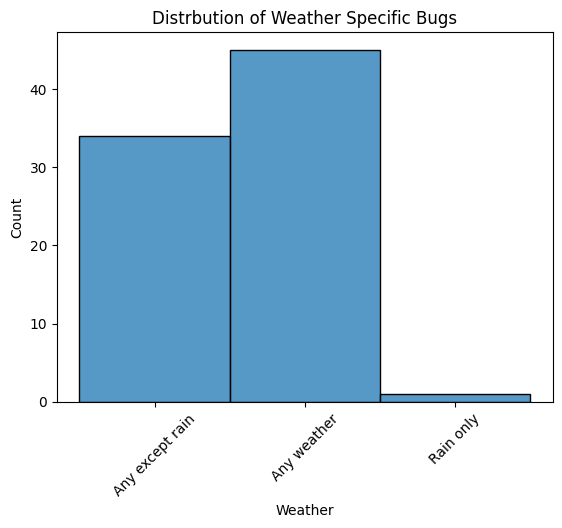

In [328]:
sns.histplot(unique_bug["weather"])
plt.xticks(rotation=45)
plt.title("Distrbution of Weather Specific Bugs")
plt.xlabel("Weather")

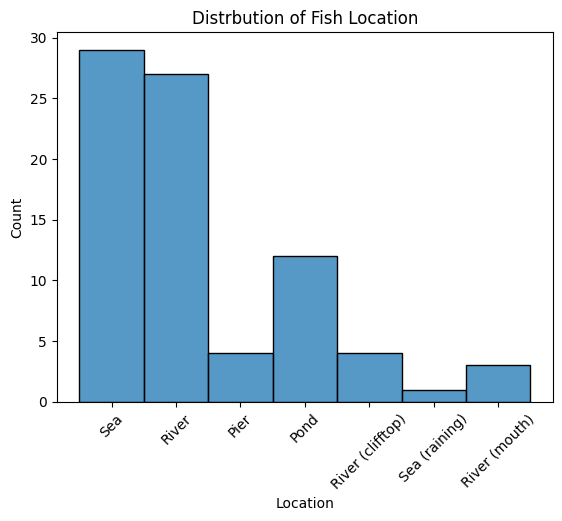

In [305]:
sns.histplot(unique_fish["location"])
plt.xticks(rotation=45)
plt.title("Distrbution of Fish Location")
plt.xlabel("Location");

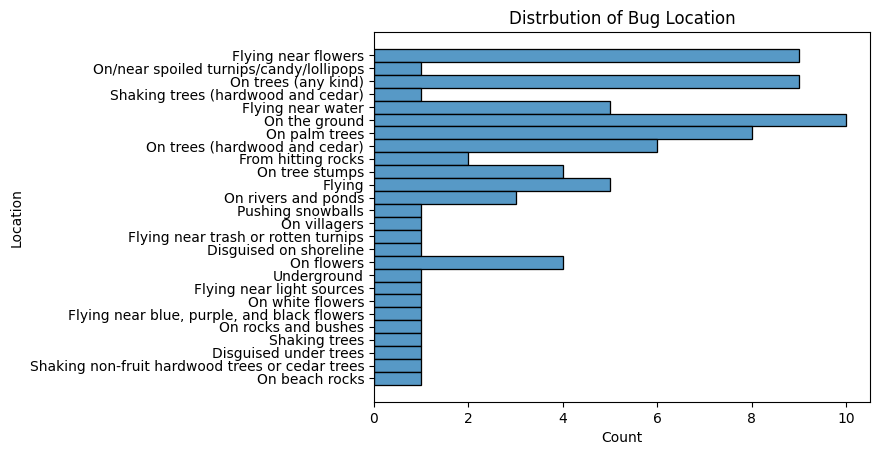

In [325]:
sns.histplot(y=unique_bug["location"])
#plt.xticks(rotation=90)
plt.title("Distrbution of Bug Location")
plt.ylabel("Location");

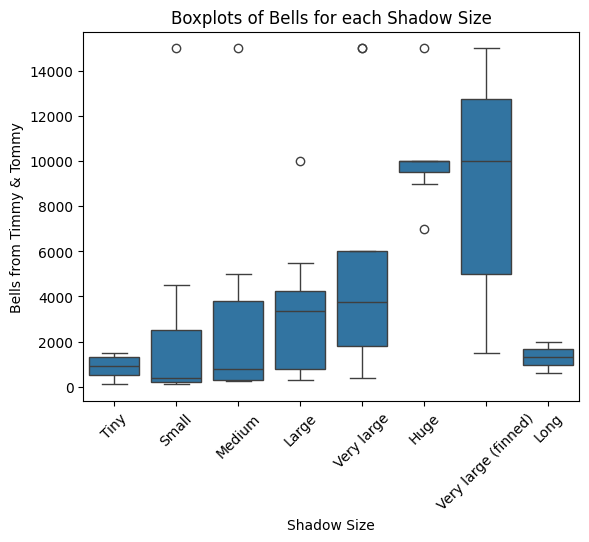

In [301]:
sns.boxplot(data=unique_fish, x="shadow_size", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Shadow Size")
plt.title("Boxplots of Bells for each Shadow Size");

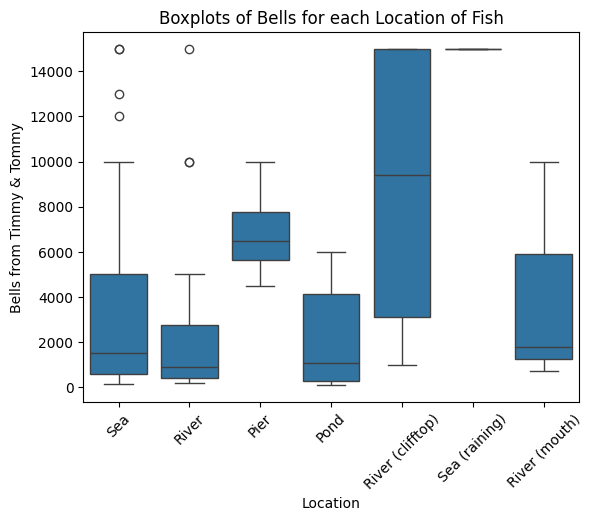

In [306]:
sns.boxplot(data=unique_fish, x="location", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Location")
plt.title("Boxplots of Bells for each Location of Fish");

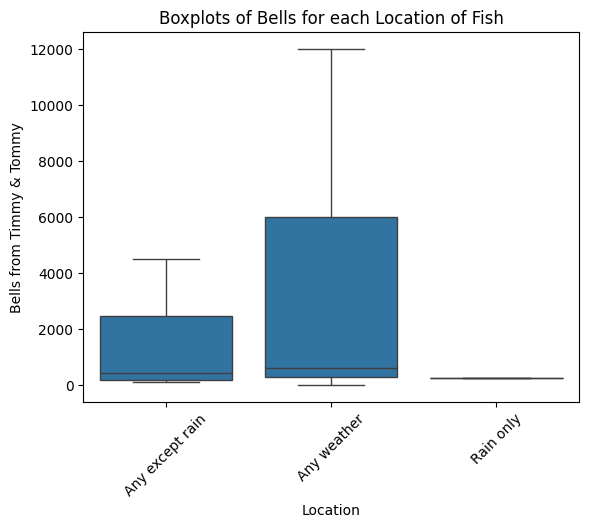

In [330]:
sns.boxplot(data=unique_bug, x="weather", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Location")
plt.title("Boxplots of Bells for each Location of Fish");

In [ ]:
sns.boxplot(data=unique_fish, x="shadow_size", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Shadow Size")
plt.title("Boxplots of Bells for each Shadow Size");